In [1]:
import numpy as np
import networkx as nx


%load_ext autoreload
%autoreload 2

In [2]:
graphs_er = np.load("../Tutorials/ER/resolution-1/graphs-1_p-0.4.npy", allow_pickle=True)
graphs_er = [g[0] for g in graphs_er]
graphs_er_110_160 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_110-160.npy", allow_pickle=True)
g_er_169 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_169.npy", allow_pickle=True)
graphs_er = graphs_er + graphs_er_110_160.tolist() + g_er_169.tolist()

graphs_pwl = np.load("../Tutorials/Power-law/resolution-1/graphs-1_m-1_p-0.1.npy", allow_pickle=True)
graphs_pwl = [g[0] for g in graphs_pwl]
graphs_pwl_110_160 = np.load("graphs/powerlaw_110-160/powerlaw_graphs_110-160.npy", allow_pickle=True)
g_pwl_169 = np.load("graphs/powerlaw_110-160/powerlaw_graph_169.npy", allow_pickle=True)
graphs_pwl = graphs_pwl + graphs_pwl_110_160.tolist() + g_pwl_169.tolist()

In [3]:
results_dir_er = f"ER/resolution-1/graphs-1_p-0.4"
results_dir_pwl = f"Power-law/resolution-1/graphs-1_m-1_p-0.1"

In [5]:
from iterative_utils import IterativeSearchGraphResults
from Qommunity.searchers.utils import HierarchicalRunMetadata
import numpy as np

graphs_results_er = {}

num_runs = 20
graphs_sizes = [int(g.number_of_nodes()) for g in graphs_er]  # 10-160 + 169

for g_size in graphs_sizes:
    hierarchical_metadatas = []
    path = results_dir_er + f"/graph_size={g_size}"

    if g_size == 169:
        path_original = results_dir_er + f"/graph_size={g_size}"
        path_100 = results_dir_er + f"/graph_size={g_size}-extra-100"

        communities_list = []
        modularities_list = []
        times_list = []
        div_mods_list = []
        div_trees_list = []


        for p in [path_100]:
            communities_list.append(np.load(f"{p}/_communities.npy", allow_pickle=True))
            modularities_list.append(np.load(f"{p}/_modularities.npy", allow_pickle=True))
            times_list.append(np.load(f"{p}/_times.npy", allow_pickle=True))
            div_mods_list.append(np.load(f"{p}/_division_modularities.npy", allow_pickle=True))
            div_trees_list.append(np.load(f"{p}/_division_trees.npy", allow_pickle=True))

        communities = np.concatenate(communities_list, axis=0)
        modularities = np.concatenate(modularities_list, axis=0)
        times = np.concatenate(times_list, axis=0)
        division_modularities = np.concatenate(div_mods_list, axis=0)
        division_trees = np.concatenate(div_trees_list, axis=0)


        hierarchical_metadatas = []

        # 100 runs
        for iter in range(100):
            base_filename = f"{path_100}/_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
    else:

        for iter in range(num_runs):
            base_filename = f"{path}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        communities = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
        modularities = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
        times = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
        division_modularities = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
        division_trees = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref=graphs_er[graphs_sizes.index(g_size)],
        graph_size=g_size,
        communities=communities,
        modularities=modularities,
        times=times,
        division_modularities=division_modularities,
        division_trees=division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_er[g_size] = iterative_graph_results

In [ ]:
from Qommunity.searchers.utils import HierarchicalRunMetadata

graphs_results_pwl = {}

num_runs = 20
graph_sizes = [int(g.number_of_nodes()) for g in graphs_er] # 10-160 + 169
base = f"./{results_dir_pwl}"


for g_size in graph_sizes:
    path = base + f"/graph_size={g_size}/"
    graphs_results_path_base =  base + f"/graph_size={g_size}/powerlaw_m=1_p=0.1"
    hierarchical_metadatas = []
    
    if g_size == 150:
        for iter in range(16):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        path = base + f"/graph_size={g_size}"
        for iter in range(3):
            base_filename = f"{path}-4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(3):
            base_filename = f"{path}-ex4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(21, 24, 1):
            base_filename = f"{path}-3runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        communities = communities[:-4]
        modularities = modularities[:-4]
        times = times[:-4]
        division_modularities = division_modularities[:-4]
        division_trees = division_trees[:-4]

        communities = np.concatenate((communities, comms_3), axis=0)
        modularities = np.concatenate((modularities, mods_3), axis=0)
        times = np.concatenate((times, times_3), axis=0)
        division_modularities = np.concatenate((division_modularities, div_mods_3), axis=0)
        division_trees = np.concatenate((division_trees, div_trees_3), axis=0)

    elif g_size == 169:
        path_original = results_dir_pwl + f"/graph_size={g_size}"
        path_10 = results_dir_pwl + f"/graph_size={g_size}-extra-10"
        path_10_2 = results_dir_pwl + f"/graph_size={g_size}-extra-10_2"
        path_20 = results_dir_pwl + f"/graph_size={g_size}-extra-20"
        path_20_2 = results_dir_pwl + f"/graph_size={g_size}-extra-20_2"
        path_20_3 = results_dir_pwl + f"/graph_size={g_size}-extra-20_3"
        path_20_4 = results_dir_pwl + f"/graph_size={g_size}-extra-20_4"

        paths = [path_10, path_10_2, path_20, path_20_2, path_20_3, path_20_4]

        hierarchical_metadatas = []
        path = results_dir_er + f"/graph_size={g_size}"

        # 10 runs
        for iter in range(10):
            base_filename = f"{path_10}/_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # 10 runs
        for iter in range(10):
            base_filename = f"{path_10_2}/_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # 20 runs
        for iter in range(20):
            base_filename = f"{path_20}/_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # 20 runs extra
        for iter in range(20):
            base_filename = f"{path_20_2}/_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # 20 runs extra
        for iter in range(20):
            base_filename = f"{path_20_3}/_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # 20 runs extra
        for iter in range(20):
            base_filename = f"{path_20_4}/_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        communities_list = []
        modularities_list = []
        times_list = []
        div_mods_list = []
        div_trees_list = []

        for p in paths:
            communities_list.append(np.load(f"{p}/_communities.npy", allow_pickle=True))
            modularities_list.append(np.load(f"{p}/_modularities.npy", allow_pickle=True))
            times_list.append(np.load(f"{p}/_times.npy", allow_pickle=True))
            div_mods_list.append(np.load(f"{p}/_division_modularities.npy", allow_pickle=True))
            div_trees_list.append(np.load(f"{p}/_division_trees.npy", allow_pickle=True))

        communities = np.concatenate(communities_list, axis=0)
        modularities = np.concatenate(modularities_list, axis=0)
        times = np.concatenate(times_list, axis=0)
        division_modularities = np.concatenate(div_mods_list, axis=0)
        division_trees = np.concatenate(div_trees_list, axis=0)
    else:
        for iter in range(num_runs):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        communities = np.load(f"{path}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times = np.load(f"{path}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        division_modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        division_trees = np.load(f"{path}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs_pwl[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = communities,
        modularities = modularities,
        times = times,
        division_modularities = division_modularities,
        division_trees = division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_pwl[g_size] = iterative_graph_results

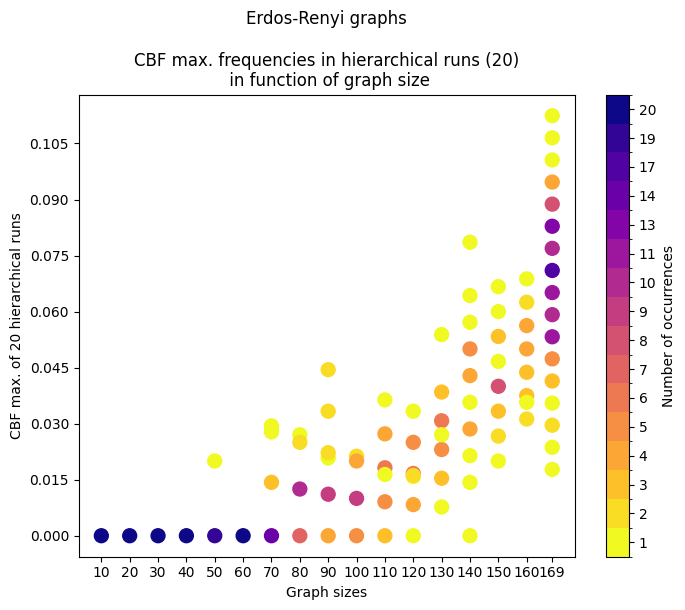

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

cbfs_maxes_per_graph_size = [graphs_results_er[g_size].cbfs_maxes for g_size in graph_sizes]
xs = [[g_size] * num_runs for g_size in graph_sizes]

all_ys = np.unique(np.concatenate(cbfs_maxes_per_graph_size))
all_x = []
all_y = []
all_counts = []

for x_row, y_row in zip(xs, cbfs_maxes_per_graph_size):
    counts = Counter(y_row)
    for y_val, count in counts.items():
        all_x.append(x_row[0])
        all_y.append(y_val)
        all_counts.append(count)

unique_counts = sorted(set(all_counts))

cmap = ListedColormap(plt.get_cmap("plasma_r")(np.linspace(0,1,len(unique_counts))))
norm = BoundaryNorm(boundaries=np.arange(len(unique_counts)+1)-0.5, ncolors=len(unique_counts))

color_indices = [unique_counts.index(c) for c in all_counts]

fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(all_x, all_y, c=color_indices, cmap=cmap, norm=norm, s=100)

ax.set_title("Erdos-Renyi graphs\n\nCBF max. frequencies in hierarchical runs (20)\n in function of graph size")
ax.set_xticks(graph_sizes)
ax.set_yticks(all_ys)
ax.set_xlabel("Graph sizes")
ax.set_ylabel("CBF max. of 20 hierarchical runs")

ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))


cbar = plt.colorbar(scatter, ticks=range(len(unique_counts)))
cbar.ax.set_yticklabels(unique_counts)
cbar.set_label("Number of occurrences")

plt.show()


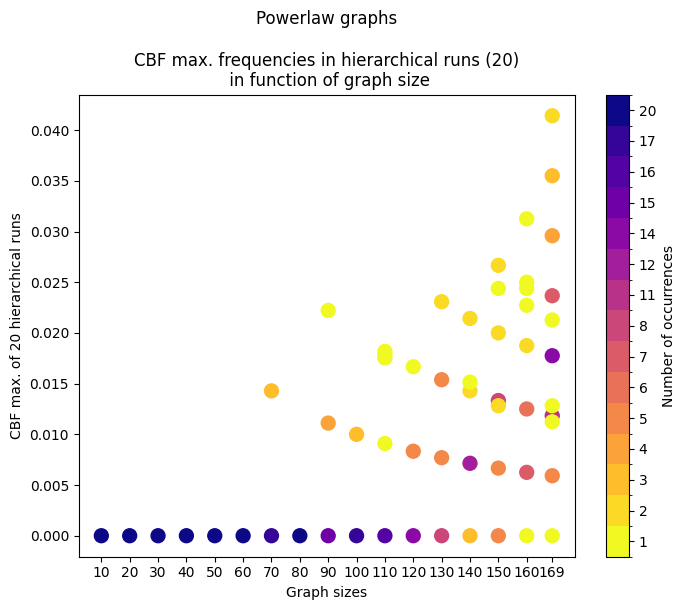

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

cbfs_maxes_per_graph_size = [graphs_results_pwl[g_size].cbfs_maxes for g_size in graph_sizes]
xs = [[g_size] * num_runs for g_size in graph_sizes]

all_ys = np.unique(np.concatenate(cbfs_maxes_per_graph_size))
all_x = []
all_y = []
all_counts = []

for x_row, y_row in zip(xs, cbfs_maxes_per_graph_size):
    counts = Counter(y_row)
    for y_val, count in counts.items():
        all_x.append(x_row[0])
        all_y.append(y_val)
        all_counts.append(count)

unique_counts = sorted(set(all_counts))

cmap = ListedColormap(plt.get_cmap("plasma_r")(np.linspace(0,1,len(unique_counts))))
norm = BoundaryNorm(boundaries=np.arange(len(unique_counts)+1)-0.5, ncolors=len(unique_counts))

color_indices = [unique_counts.index(c) for c in all_counts]

fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(all_x, all_y, c=color_indices, cmap=cmap, norm=norm, s=100)

ax.set_title("Powerlaw graphs\n\nCBF max. frequencies in hierarchical runs (20)\n in function of graph size")
ax.set_xticks(graph_sizes)
ax.set_yticks(all_ys)
ax.set_xlabel("Graph sizes")
ax.set_ylabel("CBF max. of 20 hierarchical runs")

ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

cbar = plt.colorbar(scatter, ticks=range(len(unique_counts)))
cbar.ax.set_yticklabels(unique_counts)
cbar.set_label("Number of occurrences")

plt.show()

In [9]:
# Power-law
hierarchical_metadata_pwl = graphs_results_pwl[169].hierarchical_metadatas
cbfs = np.empty((20, ), dtype=object)
for i in range(20):
    cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
modularities_pwl = graphs_results_pwl[169].modularities
communities_pwl = graphs_results_pwl[169].communities
cbfs_sums_pwl = graphs_results_pwl[169].cbfs_sum_per_run

# Erdos-Renyi
hierarchical_metadata_er = graphs_results_er[169].hierarchical_metadatas
cbfs = np.empty((20, ), dtype=object)
for i in range(20):
    cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])
modularities_er = graphs_results_er[169].modularities
communities_er = graphs_results_er[169].communities
cbfs_sums_er = graphs_results_er[169].cbfs_sum_per_run

In [10]:
# Power-law 
mods_pwl = []
cbf_max_pwl = []
cbf_avg_pwl = []
non_zero_cbfs_pwl = []
chain_strengths_pwl = []
comms_lens_pwl = []
energies_pwl = []
indices_pwl = []

for idx, sm in enumerate(hierarchical_metadata_pwl):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    if modularities_pwl[idx] is None:
        print(f"Skipping idx {idx} with modularity {modularities_pwl[idx]}")
        continue
    cbf_max_pwl.append(cbfs.max())
    cbf_avg_pwl.append(cbfs.mean())
    non_zero_cbfs_pwl.append(cbfs[non_zero_cbfs_idxs])
    indices_pwl.append(non_zero_cbfs_idxs)

    chain_strengths_pwl.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods_pwl.append(modularities_pwl[idx])
    comms_lens_pwl.append(communities_pwl[idx])


# Erdos-Renyi
mods_er = []
cbf_max_er = []
cbf_avg_er = []
non_zero_cbfs_er = []
chain_strengths_er = []
comms_lens_er = []
energies_er = []
indices_er = []

for idx, sm in enumerate(hierarchical_metadata_er[:-20]):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max_er.append(cbfs.max())
    cbf_avg_er.append(cbfs.mean())
    non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
    indices_er.append(non_zero_cbfs_idxs)

    chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods_er.append(modularities_er[idx])
    comms_lens_er.append(communities_er[idx])

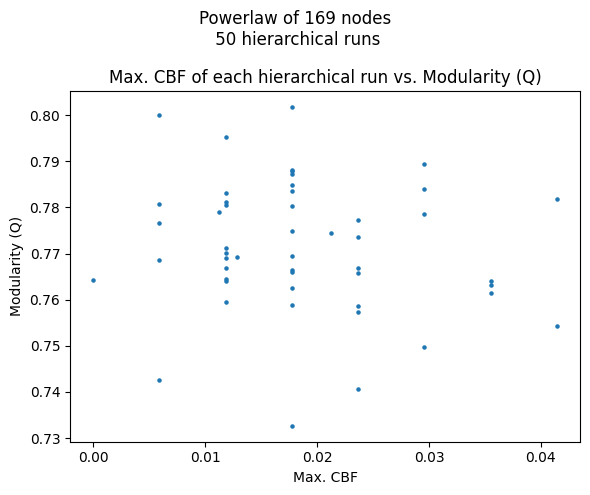

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle("Powerlaw of 169 nodes\n 50 hierarchical runs")

ax.scatter(cbf_max_pwl, mods_pwl, s=5)
ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

plt.tight_layout()
plt.show()

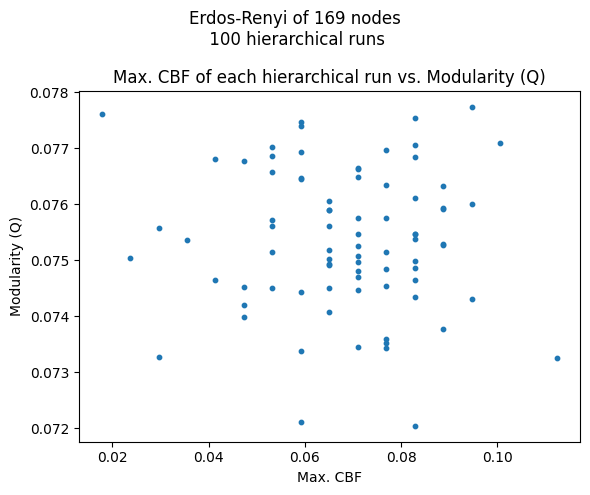

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle("Erdos-Renyi of 169 nodes\n 100 hierarchical runs")

sc = ax.scatter(cbf_max_er, mods_er, s=10)
ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

plt.tight_layout()
plt.show()

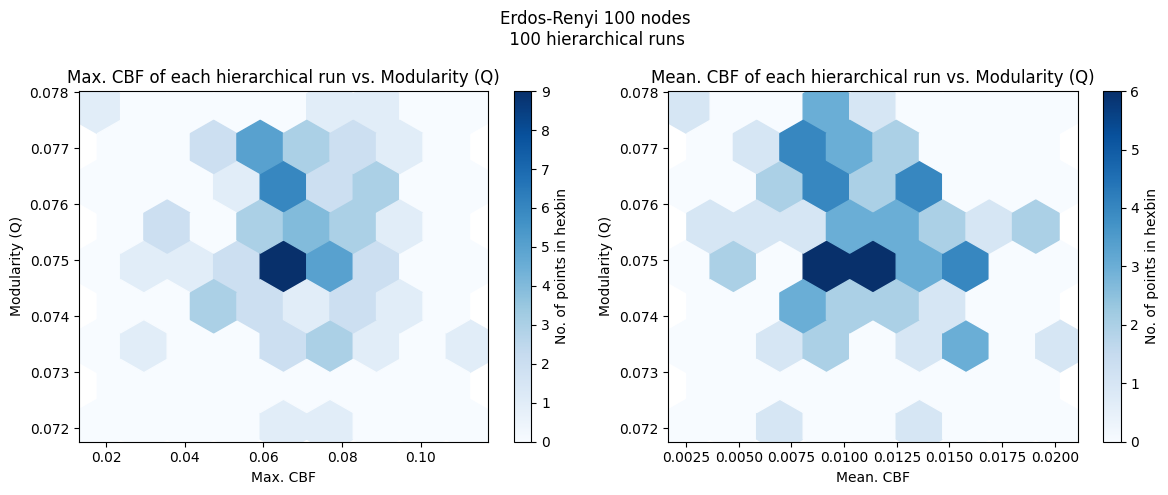

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Erdos-Renyi 100 nodes\n 100 hierarchical runs")

hb_0 = ax[0].hexbin(cbf_max_er, mods_er, cmap="Blues", gridsize=8)
cb = fig.colorbar(hb_0, ax=ax[0])
cb.set_label("No. of points in hexbin")
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

hb_1 = ax[1].hexbin(cbf_avg_er, mods_er, cmap="Blues", gridsize=8)
cb = fig.colorbar(hb_1, ax=ax[1])
cb.set_label("No. of points in hexbin")
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

ER: Pearson r = -0.047, p-value = 0.678
PWL: Pearson r = -0.142, p-value = 0.326

ER: Spearman corr = -0.011, p-value = 0.924
PWL: Spearman corr = -0.170, p-value = 0.239


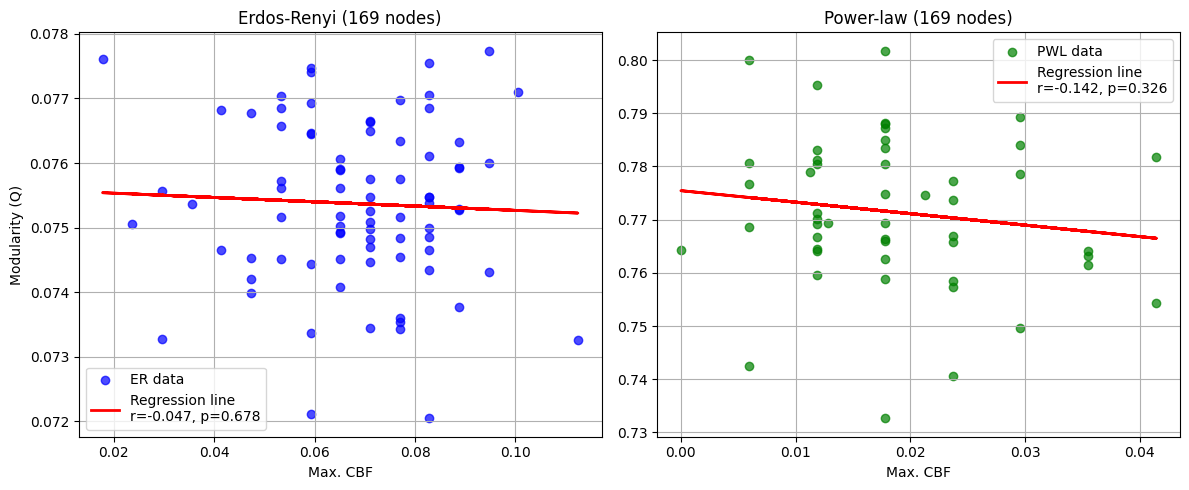

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr


x_er = np.array(cbf_max_er)
y_er = np.array(mods_er)

x_pwl = np.array(cbf_max_pwl)
y_pwl = np.array(mods_pwl)

r_er, p_er = pearsonr(x_er, y_er)
r_pwl, p_pwl = pearsonr(x_pwl, y_pwl)

print(f"ER: Pearson r = {r_er:.3f}, p-value = {p_er:.3f}")
print(f"PWL: Pearson r = {r_pwl:.3f}, p-value = {p_pwl:.3f}")
print()

corr_er, pval_er = spearmanr(x_er, y_er)
corr_pwl, pval_pwl = spearmanr(x_pwl, y_pwl)

print(f"ER: Spearman corr = {corr_er:.3f}, p-value = {pval_er:.3f}")
print(f"PWL: Spearman corr = {corr_pwl:.3f}, p-value = {pval_pwl:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(x_er, y_er, color='blue', alpha=0.7, label='ER data')
m_er, b_er = np.polyfit(x_er, y_er, 1)
axes[0].plot(x_er, m_er*x_er + b_er, color='red', lw=2,
             label=f'Regression line\nr={r_er:.3f}, p={p_er:.3f}')
axes[0].set_xlabel('Max. CBF')
axes[0].set_ylabel('Modularity (Q)')
axes[0].set_title('Erdos-Renyi (169 nodes)')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(x_pwl, y_pwl, color='green', alpha=0.7, label='PWL data')
m_pwl, b_pwl = np.polyfit(x_pwl, y_pwl, 1)
axes[1].plot(x_pwl, m_pwl*x_pwl + b_pwl, color='red', lw=2,
             label=f'Regression line\nr={r_pwl:.3f}, p={p_pwl:.3f}')
axes[1].set_xlabel('Max. CBF')
axes[1].set_title('Power-law (169 nodes)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [137]:
from Qommunity.samplers.regular.leiden_sampler import LeidenSampler
from Qommunity.searchers.regular_searcher import RegularSearcher
from Qommunity.iterative_searcher import IterativeSearcher

num_runs = 100

results_leid_er = {}
for G, g_size in zip(graphs_er, graph_sizes):
    it_searcher = IterativeSearcher(LeidenSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    
    comms, mods, times = res
    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_leid_er[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_leid_er = [results_leid_er[g_size]["modularities"] for g_size in graph_sizes]


results_leid_pwl = {}
for G, g_size in zip(graphs_pwl, graph_sizes):
    it_searcher = IterativeSearcher(LeidenSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    comms, mods, times = res

    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_leid_pwl[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_leid_pwl = [results_leid_pwl[g_size]["modularities"] for g_size in graph_sizes]


from Qommunity.samplers.regular.louvain_sampler import LouvainSampler


results_louv_er = {}
for G, g_size in zip(graphs_er, graph_sizes):
    it_searcher = IterativeSearcher(LouvainSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    comms, mods, times = res

    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_louv_er[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_louv_er = [results_louv_er[g_size]["modularities"] for g_size in graph_sizes]

results_louv_pwl = {}
for G, g_size in zip(graphs_pwl, graph_sizes):
    it_searcher = IterativeSearcher(LouvainSampler(G))
    res = it_searcher.run(num_runs=num_runs, save_results=False)
    comms, mods, times = res
    best_run_idx = np.argmax(mods)
    communities = comms[best_run_idx]
    modularity = mods[best_run_idx]
    time = times[best_run_idx]

    results_louv_pwl[g_size] = {
        "communities": communities,
        "modularities": modularity,
        "times": time
    }
mods_louv_pwl = [results_louv_pwl[g_size]["modularities"] for g_size in graph_sizes]

100%|██████████| 100/100 [00:00<00:00, 133.66it/s]


In [138]:
results_mod_maxes_er = {}
results_mod_maxes_pwl = {}
for gsize in graph_sizes:
    results_mod_maxes_er[gsize] = max(graphs_results_er[gsize].modularities)
    results_mod_maxes_pwl[gsize] = max(graphs_results_pwl[gsize].modularities)

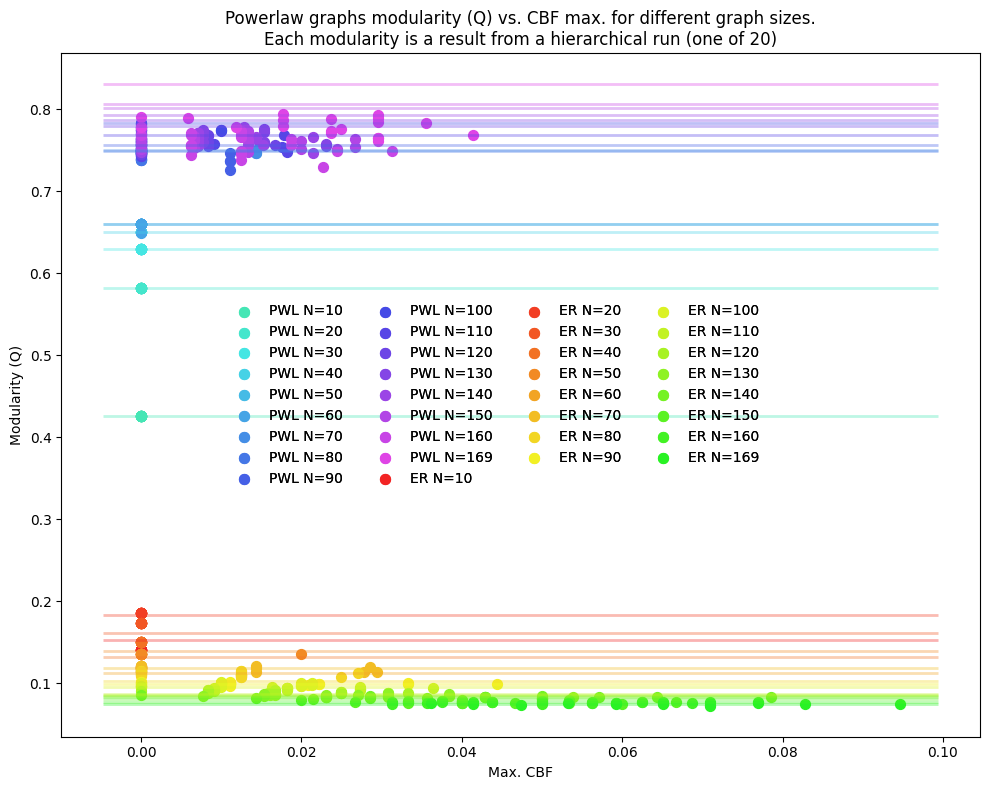

In [234]:
import matplotlib.colors as mcolors
import numpy as np
from cbf_plots import generate_strongly_contrasted_palettes


pwl_colors, er_colors = generate_strongly_contrasted_palettes(len(graph_sizes))
num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for gi, gsize in enumerate(graph_sizes):
    # Power-law
    modularities_pwl = graphs_results_pwl[gsize].modularities
    hierarchical_metadata_pwl = graphs_results_pwl[gsize].hierarchical_metadatas
    
    cbfs_pwl = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs_pwl[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])


    # Erdos-Renyi
    modularities_er = graphs_results_er[gsize].modularities
    hierarchical_metadata_er = graphs_results_er[gsize].hierarchical_metadatas
    
    cbfs_er = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs_er[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])


    # Power-law
    mods_pwl = []
    cbf_max_pwl = []

    for idx, sm in enumerate(hierarchical_metadata_pwl):
        if idx >= num_runs:
            continue

        cbfs = np.array(sm.chain_break_fraction)
        cbf_max_pwl.append(cbfs.max())
        mods_pwl.append(modularities_pwl[idx])


    # Erdos-Renyi
    mods_er = []
    cbf_max_er = []

    for idx, sm in enumerate(hierarchical_metadata_er):
        if idx >= num_runs:
            continue

        cbfs = np.array(sm.chain_break_fraction)
        cbf_max_er.append(cbfs.max())
        mods_er.append(modularities_er[idx])

    pwl_color = pwl_colors[gi]
    er_color  = er_colors[gi]
    
    ax.scatter(cbf_max_pwl, mods_pwl, s=50, color=pwl_color, label=f"PWL N={gsize}")
    ax.scatter(cbf_max_er, mods_er, s=50, color=er_color, label=f"ER N={gsize}")


handles, labels = ax.get_legend_handles_labels()
pwl_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("PWL")]
er_items  = [(h, l) for h, l in zip(handles, labels) if l.startswith("ER")]

ordered_handles = [h for h, _ in pwl_items + er_items]
ordered_labels  = [l for _, l in pwl_items + er_items]

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="center",
    ncol=4,
    frameon=False
)

xmin, xmax = ax.get_xlim()

# Referential lines
for i, gsize in enumerate(graph_sizes):
    # Power-law
    ax.hlines(
        y=mods_leid_pwl[i],
        xmin=xmin,
        xmax=xmax,
        colors=pwl_colors[i],
        linewidth=2,
        alpha=0.35,
        label=f"PWL Leiden max N={gsize}"
    )
    # Erdos-Renyi
    ax.hlines(
        y=mods_leid_er[i],
        xmin=xmin,
        xmax=xmax,
        colors=er_colors[i],
        linewidth=2,
        alpha=0.35,
        label=f"ER Leiden max N={gsize}"
    )

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="center",
    ncol=4,
    frameon=False
)

ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Powerlaw graphs modularity (Q) vs. CBF max. for different graph sizes.\nEach modularity is a result from a hierarchical run (one of 20)");

plt.savefig("modularity_cbf_common_with_refs.svg", format="svg", bbox_inches="tight", pad_inches=1)
plt.tight_layout()
plt.show()

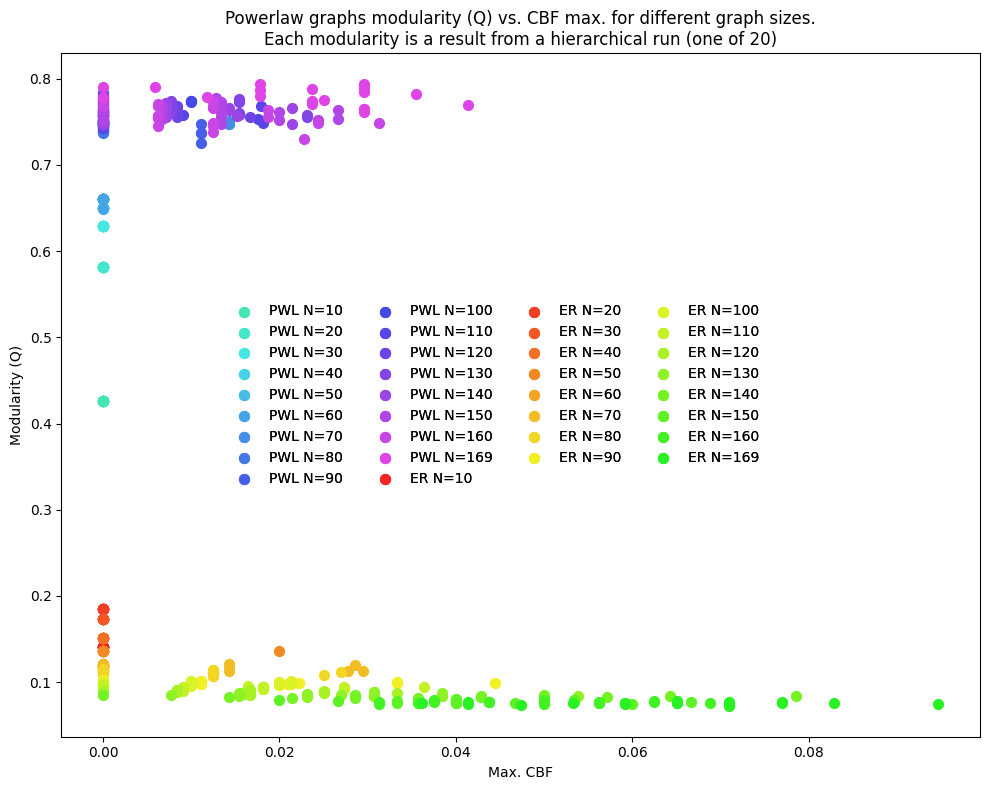

In [233]:
import matplotlib.colors as mcolors
import numpy as np
from cbf_plots import generate_strongly_contrasted_palettes


pwl_colors, er_colors = generate_strongly_contrasted_palettes(len(graph_sizes))
num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for gi, gsize in enumerate(graph_sizes):
    # Power-law
    modularities_pwl = graphs_results_pwl[gsize].modularities
    hierarchical_metadata_pwl = graphs_results_pwl[gsize].hierarchical_metadatas
    
    cbfs_pwl = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs_pwl[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])


    # Erdos-Renyi
    modularities_er = graphs_results_er[gsize].modularities
    hierarchical_metadata_er = graphs_results_er[gsize].hierarchical_metadatas
    
    cbfs_er = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs_er[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])


    # Power-law
    mods_pwl = []
    cbf_max_pwl = []

    for idx, sm in enumerate(hierarchical_metadata_pwl):
        if idx >= num_runs:
            continue

        cbfs = np.array(sm.chain_break_fraction)
        cbf_max_pwl.append(cbfs.max())
        mods_pwl.append(modularities_pwl[idx])


    # Erdos-Renyi
    mods_er = []
    cbf_max_er = []

    for idx, sm in enumerate(hierarchical_metadata_er):
        if idx >= num_runs:
            continue

        cbfs = np.array(sm.chain_break_fraction)
        cbf_max_er.append(cbfs.max())
        mods_er.append(modularities_er[idx])

    pwl_color = pwl_colors[gi]
    er_color  = er_colors[gi]
    
    ax.scatter(cbf_max_pwl, mods_pwl, s=50, color=pwl_color, label=f"PWL N={gsize}")
    ax.scatter(cbf_max_er, mods_er, s=50, color=er_color, label=f"ER N={gsize}")


handles, labels = ax.get_legend_handles_labels()
pwl_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("PWL")]
er_items  = [(h, l) for h, l in zip(handles, labels) if l.startswith("ER")]

ordered_handles = [h for h, _ in pwl_items + er_items]
ordered_labels  = [l for _, l in pwl_items + er_items]

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="center",
    ncol=4,
    frameon=False
)

xmin, xmax = ax.get_xlim()

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="center",
    ncol=4,
    frameon=False
)

ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Powerlaw graphs modularity (Q) vs. CBF max. for different graph sizes.\nEach modularity is a result from a hierarchical run (one of 20)");

plt.savefig("modularity_cbf_common.svg", format="svg", bbox_inches="tight", pad_inches=1)
plt.tight_layout()
plt.show()

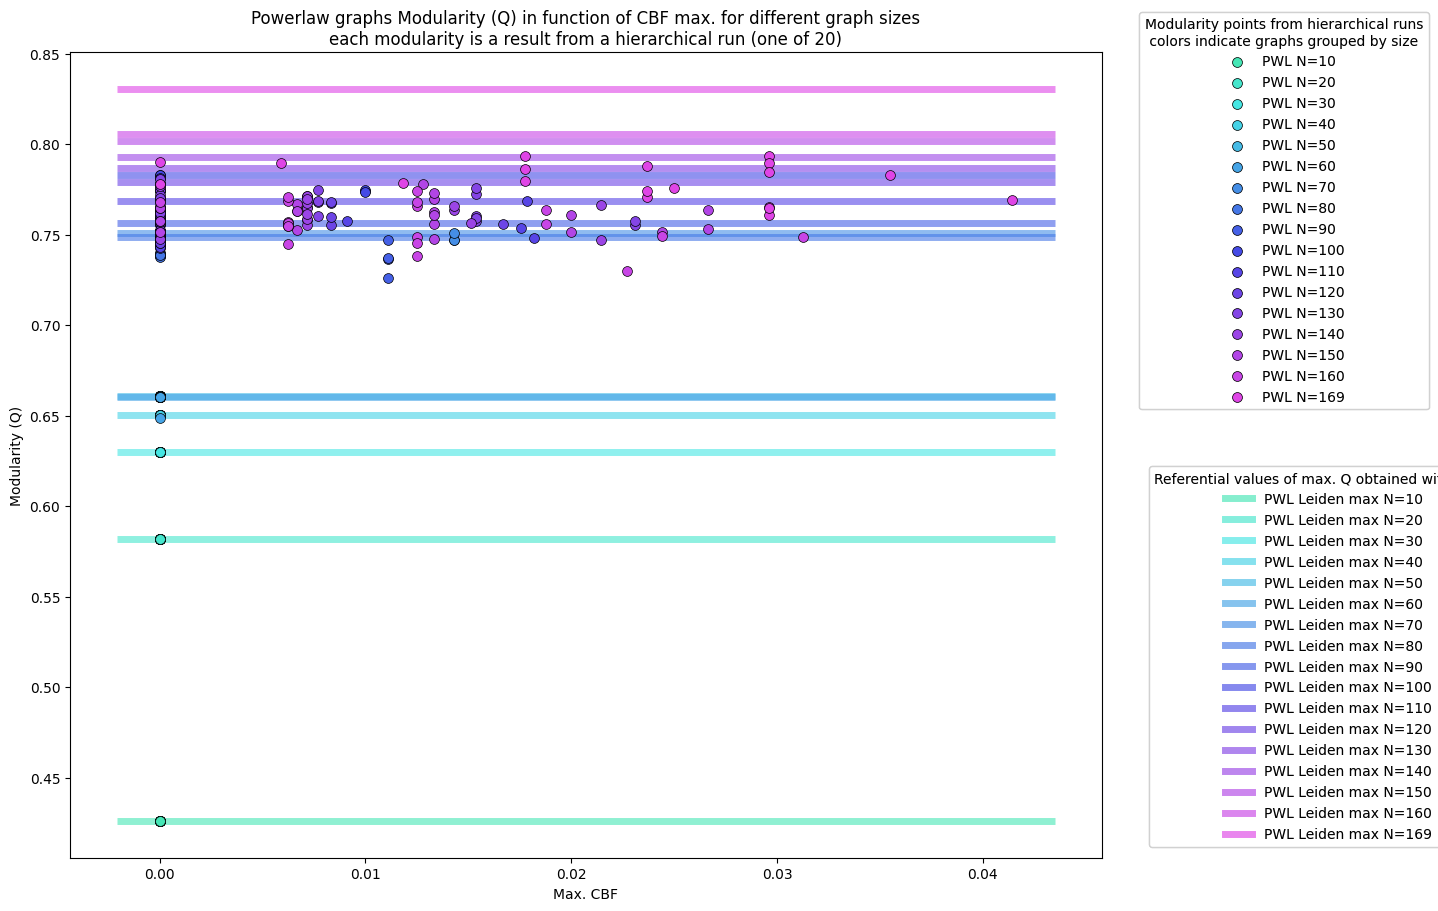

In [229]:
import matplotlib.colors as mcolors
import numpy as np
from cbf_plots import generate_strongly_contrasted_palettes


pwl_colors, er_colors = generate_strongly_contrasted_palettes(len(graph_sizes))
num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(11, 9), constrained_layout=True)

for gi, gsize in enumerate(graph_sizes):
    # Power-law
    modularities_pwl = graphs_results_pwl[gsize].modularities
    hierarchical_metadata_pwl = graphs_results_pwl[gsize].hierarchical_metadatas
    
    cbfs_pwl = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs_pwl[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])

    # Power-law
    mods_pwl = []
    cbf_max_pwl = []

    for idx, sm in enumerate(hierarchical_metadata_pwl):
        if idx >= num_runs:
            continue

        cbfs = np.array(sm.chain_break_fraction)
        cbf_max_pwl.append(cbfs.max())
        mods_pwl.append(modularities_pwl[idx])

    pwl_color = pwl_colors[gi]

    ax.scatter(cbf_max_pwl, mods_pwl, s=50, color=pwl_color, label=f"PWL N={gsize}", edgecolors='k', linewidths=0.5, zorder=3)


xmin, xmax = ax.get_xlim()

LINE_ALPHA = 0.6

# Referential lines
for i, gsize in enumerate(graph_sizes):
    # Power-law
    ax.hlines(
        y=mods_leid_pwl[i],
        xmin=xmin,
        xmax=xmax,
        colors=pwl_colors[i],
        linewidth=5,
        alpha=LINE_ALPHA,
        label=f"PWL Leiden max N={gsize}"
    )


ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Powerlaw graphs Modularity (Q) in function of CBF max. for different graph sizes\neach modularity is a result from a hierarchical run (one of 20)");


handles, labels = ax.get_legend_handles_labels()
pwl_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("PWL N")]

ordered_handles = [h for h, _ in pwl_items]
ordered_labels  = [l for _, l in pwl_items]


legend_title=f"Modularity points from hierarchical runs\n colors indicate graphs grouped by size"
legend1 = fig.legend(
    ordered_handles,
    ordered_labels,
    loc='upper right',
    bbox_to_anchor=(1.3, 1),
    # ncol=4,
    # frameon=False
    title=legend_title,
)
ax.add_artist(legend1)


from matplotlib.lines import Line2D


hl_handles = []
hl_labels = []
for i, gsize in enumerate(graph_sizes):
    proxy = Line2D([0], [0], color=pwl_colors[i], lw=5, alpha=LINE_ALPHA)
    hl_handles.append(proxy)
    hl_labels.append(f"PWL Leiden max N={gsize}")

legend2 = ax.legend(
    hl_handles,
    hl_labels,
    loc='center right',
    bbox_to_anchor=(1.4, 0.25),
    title="Referential values of max. Q obtained with Leiden",
    frameon=True
)
ax.add_artist(legend2)


plt.savefig("modularity_cbf_PWL.svg", format="svg", bbox_inches="tight", pad_inches=1)
plt.show()

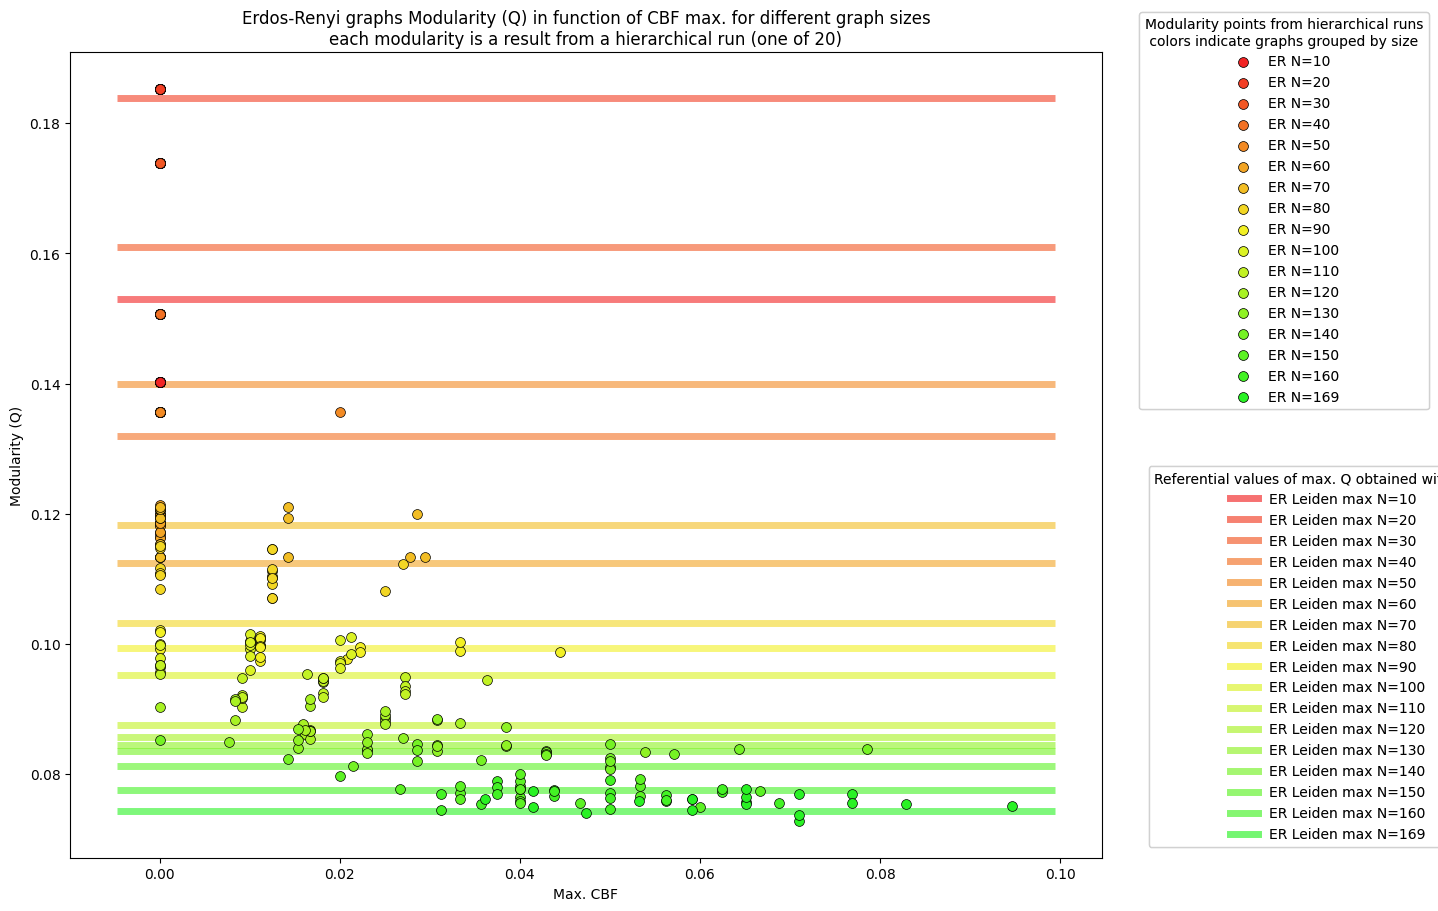

In [228]:
import matplotlib.colors as mcolors
import numpy as np
from cbf_plots import generate_strongly_contrasted_palettes


pwl_colors, er_colors = generate_strongly_contrasted_palettes(len(graph_sizes))
num_runs = 19

fig, ax = plt.subplots(1, 1, figsize=(11, 9), constrained_layout=True)

for gi, gsize in enumerate(graph_sizes):
    # Erdos-Renyi
    modularities_er = graphs_results_er[gsize].modularities
    hierarchical_metadata_er = graphs_results_er[gsize].hierarchical_metadatas
    
    cbfs_er = np.empty((num_runs, ), dtype=object)
    for i in range(num_runs):
        cbfs_er[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])

    # Erdos-Renyi
    mods_er = []
    cbf_max_er = []
    for idx, sm in enumerate(hierarchical_metadata_er):
        if idx >= num_runs:
            continue

        cbfs = np.array(sm.chain_break_fraction)
        cbf_max_er.append(cbfs.max())
        mods_er.append(modularities_er[idx])

    er_color = er_colors[gi]

    ax.scatter(cbf_max_er, mods_er, s=50, color=er_color, label=f"ER N={gsize}", edgecolors='k', linewidths=0.5, zorder=3)


xmin, xmax = ax.get_xlim()

LINE_ALPHA = 0.6

# Referential lines
for i, gsize in enumerate(graph_sizes):
    # Erdos-Renyi
    ax.hlines(
        y=mods_leid_er[i],
        xmin=xmin,
        xmax=xmax,
        colors=er_colors[i],
        linewidth=5,
        alpha=LINE_ALPHA,
        label=f"ER Leiden max N={gsize}"
    )


ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Erdos-Renyi graphs Modularity (Q) in function of CBF max. for different graph sizes\neach modularity is a result from a hierarchical run (one of 20)");


handles, labels = ax.get_legend_handles_labels()
er_items = [(h, l) for h, l in zip(handles, labels) if l.startswith("ER N")]
ordered_handles = [h for h, _ in er_items]
ordered_labels  = [l for _, l in er_items]


legend_title=f"Modularity points from hierarchical runs\n colors indicate graphs grouped by size"
legend1 = fig.legend(
    ordered_handles,
    ordered_labels,
    loc='upper right',
    bbox_to_anchor=(1.3, 1),
    # ncol=4,
    # frameon=False
    title=legend_title,
)
ax.add_artist(legend1)


from matplotlib.lines import Line2D


hl_handles = []
hl_labels = []
for i, gsize in enumerate(graph_sizes):
    proxy = Line2D([0], [0], color=er_colors[i], lw=5, alpha=LINE_ALPHA)
    hl_handles.append(proxy)
    hl_labels.append(f"ER Leiden max N={gsize}")

legend2 = ax.legend(
    hl_handles,
    hl_labels,
    loc='center right',
    bbox_to_anchor=(1.4, 0.25),
    title="Referential values of max. Q obtained with Leiden",
    frameon=True
)
ax.add_artist(legend2)


plt.savefig("modularity_cbf_ER.svg", format="svg", bbox_inches="tight", pad_inches=1)
plt.show()

In [235]:
scatter_collections = [
    c for c in ax.collections
    if isinstance(c, plt.matplotlib.collections.PathCollection)
]

n_points = sum(len(c.get_offsets()) for c in scatter_collections)
print("Total scattered points (drawn):", n_points)# 17 x 20 x 2 = 680

Total scattered points (drawn): 646
